# Assignment 5

Assume you work for a record company. Your boss is interested in predicting ablum sales based on advertising. You are provided with the data in a file (*album_sales.csv*). 

There are 200 rows, where each row represents an album. There are also four columns. The first (*sales*) represents the sales of each album (in thousands) the week after release. The second (adverts) represents the amount (in thousands $) spent promoting the album prior to its release. The third (*airplay*) represents how many times it played on the radio. The fourth column (*attract*) represents the attractiveness of the band. 

## Instructions

### 1. Visualization (15 points)

Visualizing data is important to get a 'feel' of what the relationship between variables could be. For this part, **display the scatterplots between the following variables**.

- *sales* and *adverts*
- *sales* and *airplay*
- *sales* and *attract*

Text(0.5, 1.0, '')

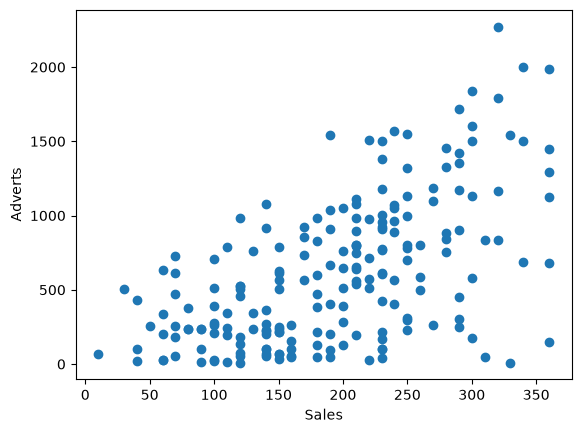

In [41]:
# Code here

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

df = pd.read_csv("./album_sales.csv")


df.head()

# df.describe()


plt.scatter(df['sales'], df['adverts'])
plt.xlabel("Sales")
plt.ylabel("Adverts")
plt.title("")






Text(0.5, 1.0, 'Sales to Airplay')

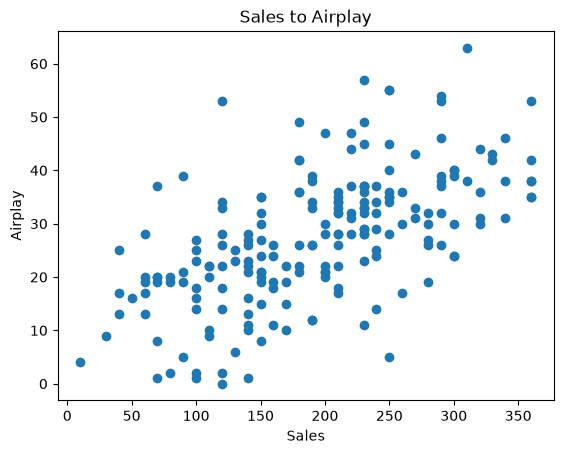

In [22]:

plt.scatter(df['sales'], df['airplay'])
plt.xlabel("Sales")
plt.ylabel("Airplay")
plt.title("Sales to Airplay")


Text(0.5, 1.0, 'Sales to Attract')

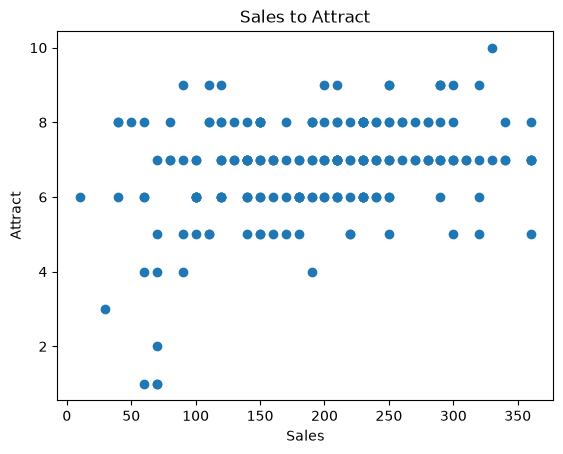

In [23]:

plt.scatter(df['sales'], df['attract'])
plt.xlabel("Sales")
plt.ylabel("Attract")
plt.title("Sales to Attract")

In the empty `Markdown` cell below, describe the relationship (or lack thereof) portrayed by the scatterplots you generated. 

### 2. Linear Regression (35 points)

- Conduct a linear regression to construct a linear model between *sales* and *adverts*
- Display the **F-statistic** and **P-value**
    - Use the `statsmodels.api` module for this -- may need to install via `pip`
    - Note that **X**, your predictor(s), will consist of *adverts* and that **y**, your constant, will consist of *sales*
    - The values you need can be accessed via the `summary()` function of your model object

In [20]:
# Code here

import statsmodels.api as sm


x = df['adverts']
y = df['sales']
x = sm.add_constant(x)

model = sm.OLS(y, x).fit()
predictions = model.predict(x) # will be used later
print(model.summary())

print(f"f-statistic : {model.fvalue}")
print(f"p-value : {model.f_pvalue}")


                            OLS Regression Results                            
Dep. Variable:                  sales   R-squared:                       0.335
Model:                            OLS   Adj. R-squared:                  0.331
Method:                 Least Squares   F-statistic:                     99.59
Date:                Wed, 16 Sep 2026   Prob (F-statistic):           2.94e-19
Time:                        14:38:43   Log-Likelihood:                -1120.7
No. Observations:                 200   AIC:                             2245.
Df Residuals:                     198   BIC:                             2252.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        134.1399      7.537     17.799      0.0

In the empty `Markdown` cell below, describe whether the **F-statistic** and **P-value** describe about our linear regression model. (I.e., Is it good? Bad? No bearing?)

The f-statistic is very high as it is measured as 99.587 and the p-value is very low (under 0.05). This indicates that the regression has an overall high statistical significance, and since the p-value is less than 0.05, you reject the null hypothesis and there is not a linear relationship between the two variables. This shows that sales and adverts have a statistically significant 

### 3. Model Coefficients (10 points)

- Make note of the **intercept** value and **coefficient** (adverts) value of your linear regression model. 

The regression line is described using this equation: *Y = b<sub>0</sub> + b<sub>1</sub>X<sub>1</sub>* where each variable represents the following:

- Y denotes the sales
- *b<sub>0</sub>* denotes the **intercept** value
- *b<sub>1</sub>* denotes the advertising budget **coefficient**
- *X<sub>2</sub>* denotes the advertising budget

The equation then becomes *Album Sales = intercept value + (coefficient * advertising budget)*. 

Using the intercept value and coefficient of your linear model, **calculate and display how many records will be sold if $135,000 was spent on advertising an album**.

In [42]:
# Code here
x = df['adverts']
y = df['sales']

x = sm.add_constant(x)

model = sm.OLS(y, x).fit()
predictions = model.predict(x) # will be used later
# print(model.summary())

intercept = model.params['const']
coefficient = model.params['adverts']

print(f"intercept : {intercept}")
print(f"coefficient : {coefficient}")

advertisement_money = 135

sales = intercept + (coefficient * advertisement_money)
print(f"The predicted sales for albums would be: {sales}")

intercept : 134.13993781207427
coefficient : 0.09612448597387711
The predicted sales for albums would be: 147.11674341854768


### 4. Multiple Regression (40 points)
- Conduct a **multiple regression** to construct a model between *sales* and the predictors (*adverts*, *airplay*, and *attract*)
    - Note that **X**, your predictors will consist of *adverts*, *airplay*, and *attractiveness*, and **y**, your constant, will consist of *sales*
- Display the summary of the multiple regression model using the `summary()` function to obtain the relevant values

In [43]:
# Code here
x = df[['adverts','airplay', 'attract']]
y = df['sales']
x = sm.add_constant(x)

model = sm.OLS(y, x).fit()
predictions = model.predict(x) # will be used later
print(model.summary())

print(model.f_pvalue)


                            OLS Regression Results                            
Dep. Variable:                  sales   R-squared:                       0.665
Model:                            OLS   Adj. R-squared:                  0.660
Method:                 Least Squares   F-statistic:                     129.5
Date:                Wed, 16 Sep 2026   Prob (F-statistic):           2.88e-46
Time:                        14:53:27   Log-Likelihood:                -1052.2
No. Observations:                 200   AIC:                             2112.
Df Residuals:                     196   BIC:                             2126.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        -26.6130     17.350     -1.534      0.1

We know that the R<sup>2</sup> (R-Squared) value can be used to evaluate the overall fit of a linear model. We also know that R<sup>2</sup> is between 0 and 1 -- higher values are better because it means that more variance is explained by the model. **Higher R<sup>2</sup> values are better if their P-values are < 0.05**.

Bsed on this, discuss **which one of the two models you constructed is better** in the empty `Markdown` cell below. 
* Model 1: The linear model between *sales* and *adverts* you constructed
* Model 2: The multiple regression model between (*sales*) and the predictors (*adverts*, *airplay*, and *attract*) you constructed

The R^2 value for the first model was 0.335, while the second model had 0.665. Both of the p-values for the models are below 0.05, which would mean that model 2 is better.

### Submission
- Submit this `Jupyter` file to D2L, renamed as **Last_First_Assignment4.ipynb** 
    - Replace '**Last**' and '**First**' with your first and last name